<a href="https://colab.research.google.com/github/njwbilll/Tugas-2_scikit-learn-Cookbook-O-Reilly-_Najwa-Bilqis-Al-Khalidah/blob/main/07_Support_Vector_Machines_and_Kernel_Methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 7: Support Vector Machines and Kernel Methods

**Referensi:** scikit-learn Cookbook, Third Edition - John Sukup (Packt Publishing, 2025)

---

## Ringkasan Chapter

Chapter 7 membahas Support Vector Machines (SVM), salah satu algoritma ML paling kuat yang menggunakan konsep geometri untuk memisahkan kelas dalam ruang fitur. Inti dari SVM adalah menemukan **hyperplane** yang memaksimalkan margin antara dua kelas. Ketika data tidak dapat dipisahkan secara linear, SVM menggunakan **kernel trick** untuk memetakan data ke dimensi yang lebih tinggi di mana pemisahan linear menjadi mungkin. Menariknya, ini adalah satu dari sedikit kasus dalam ML di mana menambah dimensi justru membantu!

### Topik yang Dibahas:
1. Pengantar SVM: hyperplane, support vectors, dan margin
2. Kernel functions: Linear, Polynomial, dan RBF
3. Tuning hyperparameter SVM (C, gamma, degree)
4. SVM pada data berdimensi tinggi
5. Evaluasi model SVM (classification report, ROC curve)
6. Latihan praktis


---
## Setup: Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

np.random.seed(2024)
print("Library berhasil diimport.")


Library berhasil diimport.


---
## 1. Pengantar SVM

### Penjelasan Teori

**Support Vector Machine (SVM)** adalah algoritma ML supervised yang sangat efektif untuk tugas klasifikasi dan regresi, terutama ketika data berdimensi tinggi atau kelas-kelasnya tidak mudah dipisahkan.

**Konsep inti SVM:**

1. **Hyperplane:** Decision boundary yang memisahkan data menjadi kelas-kelas yang berbeda. Dalam 2D, ini adalah sebuah garis; dalam 3D, ini adalah sebuah bidang; dan dalam dimensi yang lebih tinggi, ini adalah hyperplane.

2. **Support Vectors:** Titik-titik data yang paling dekat dengan hyperplane. Hanya titik-titik ini yang menentukan posisi dan orientasi hyperplane. Ini berbeda dari banyak algoritma lain yang mempertimbangkan semua titik data.

3. **Margin:** Jarak antara hyperplane dan support vectors terdekat dari setiap kelas. SVM berusaha **memaksimalkan margin** ini. Margin yang lebih besar umumnya berarti kemampuan generalisasi yang lebih baik.

4. **Soft Margin:** Di dunia nyata, data sering tidak perfectly separable. Soft margin memungkinkan beberapa misklasifikasi yang dikontrol oleh parameter `C`:
   - `C` besar: penalty tinggi untuk misklasifikasi, margin lebih sempit, bisa overfit.
   - `C` kecil: toleransi lebih tinggi terhadap misklasifikasi, margin lebih lebar, lebih robust.

**SVM untuk regresi:** `SVR` (Support Vector Regression) menggunakan konsep yang sama untuk tugas regresi, mencari hyperplane yang memprediksi nilai target dengan margin toleransi epsilon.


In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC, SVR
from sklearn.metrics import accuracy_score, classification_report

# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=2024
)

# SVM Classifier dengan kernel linear (default)
svm_classifier = SVC(kernel='linear', random_state=2024)
svm_classifier.fit(X_train, y_train)
y_pred_svm = svm_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_svm)
print(f"SVM (kernel=linear) - Accuracy: {accuracy:.4f}")
print(f"Jumlah Support Vectors per kelas: {svm_classifier.n_support_}")


SVM (kernel=linear) - Accuracy: 0.9333
Jumlah Support Vectors per kelas: [ 3 10  8]


In [3]:
# Classification report
report_df = pd.DataFrame(
    classification_report(y_test, y_pred_svm, target_names=iris.target_names, output_dict=True)
).transpose()
print("Classification Report - SVM (Linear Kernel, Iris):")
display(report_df.round(4))


Classification Report - SVM (Linear Kernel, Iris):


,precision,recall,f1-score,support
setosa,1.0000,1.0000,1.0000,18.0000
versicolor,0.9091,0.8333,0.8696,12.0000
virginica,0.8750,0.9333,0.9032,15.0000
accuracy,0.9333,0.9333,0.9333,0.9333
macro avg,0.9280,0.9222,0.9243,45.0000
weighted avg,0.9341,0.9333,0.9330,45.0000


In [4]:
# SVM untuk Regresi (SVR)
from sklearn.metrics import mean_squared_error

# Gunakan dua fitur pertama untuk demonstrasi SVR
svm_regressor = SVR(kernel='rbf')
svm_regressor.fit(X_train[:, :2], y_train)
y_pred_reg = svm_regressor.predict(X_test[:, :2])

mse = mean_squared_error(y_test, y_pred_reg)
print(f"SVR (kernel=rbf) - MSE: {mse:.4f}")
print("(MSE rendah berarti prediksi mendekati nilai aktual)")


SVR (kernel=rbf) - MSE: 0.2037
(MSE rendah berarti prediksi mendekati nilai aktual)


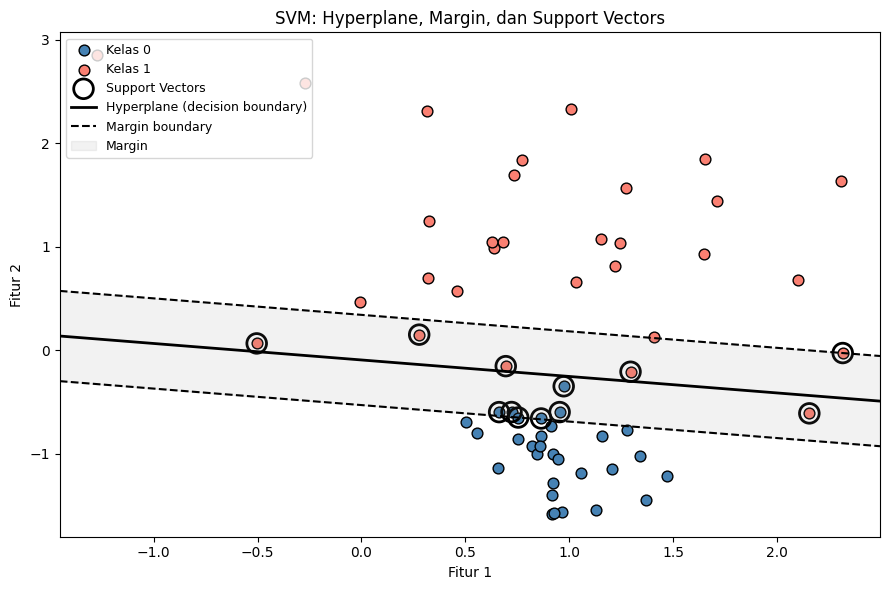

In [5]:
# Visualisasi intuitif: konsep margin dan support vectors (dataset 2D sintetis)
from sklearn.datasets import make_classification

X_vis, y_vis = make_classification(
    n_samples=60, n_features=2, n_informative=2,
    n_redundant=0, n_clusters_per_class=1, random_state=42
)

svm_vis = SVC(kernel='linear', C=1.0)
svm_vis.fit(X_vis, y_vis)

fig, ax = plt.subplots(figsize=(9, 6))

# Plot data points
ax.scatter(X_vis[y_vis==0, 0], X_vis[y_vis==0, 1],
           color='steelblue', label='Kelas 0', edgecolors='k', s=60)
ax.scatter(X_vis[y_vis==1, 0], X_vis[y_vis==1, 1],
           color='salmon', label='Kelas 1', edgecolors='k', s=60)

# Plot support vectors
sv = svm_vis.support_vectors_
ax.scatter(sv[:, 0], sv[:, 1], s=200, linewidths=2,
           facecolors='none', edgecolors='black', label='Support Vectors')

# Plot hyperplane dan margin
xlim = ax.get_xlim()
ylim = ax.get_ylim()
xx = np.linspace(xlim[0], xlim[1], 100)
w  = svm_vis.coef_[0]
b  = svm_vis.intercept_[0]

yy_hp = -(w[0] * xx + b) / w[1]
margin = 1 / np.sqrt(np.sum(w ** 2))
yy_up  = yy_hp + margin * np.sqrt(1 + (w[0]/w[1])**2)
yy_dn  = yy_hp - margin * np.sqrt(1 + (w[0]/w[1])**2)

ax.plot(xx, yy_hp, 'k-',  linewidth=2, label='Hyperplane (decision boundary)')
ax.plot(xx, yy_up, 'k--', linewidth=1.5, label='Margin boundary')
ax.plot(xx, yy_dn, 'k--', linewidth=1.5)
ax.fill_between(xx, yy_dn, yy_up, alpha=0.1, color='gray', label='Margin')

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel('Fitur 1')
ax.set_ylabel('Fitur 2')
ax.set_title('SVM: Hyperplane, Margin, dan Support Vectors')
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()


---
## 2. Kernel Functions dan Aplikasinya

### Penjelasan Teori

**Kernel trick** adalah teknik matematika yang memungkinkan SVM beroperasi di ruang dimensi tinggi tanpa secara eksplisit menghitung koordinat data dalam ruang tersebut. Ini dilakukan hanya dengan menghitung dot product antar titik data dalam ruang berdimensi tinggi menggunakan fungsi kernel.

Analogi: bayangkan sebuah akordeon. Saat dikompres, data titik-titik saling tumpang tindih dan tidak bisa dipisahkan dengan garis. Saat direntangkan (pemetaan ke dimensi lebih tinggi), titik-titik tersebar dan bisa dipisahkan dengan hyperplane linear. Saat akordeon dikompres kembali, boundary linear tersebut berubah menjadi kurva non-linear di ruang asli.

**Tiga kernel utama:**

1. **Linear Kernel** `K(x_i, x_j) = x_i^T * x_j`
   - Tidak ada transformasi. Bekerja langsung di ruang asli.
   - Cocok untuk: data yang bisa dipisahkan secara linear, dataset dengan banyak fitur.

2. **Polynomial Kernel** `K(x_i, x_j) = (gamma * x_i^T * x_j + coef0)^degree`
   - Memetakan data ke ruang polinomial.
   - Cocok untuk: data dengan hubungan polinomial antar fitur.
   - Parameter kunci: `degree` (derajat polinomial).

3. **RBF (Radial Basis Function) / Gaussian Kernel** `K(x_i, x_j) = exp(-gamma * ||x_i - x_j||^2)`
   - Kernel paling populer. Dapat menangani hubungan non-linear yang sangat kompleks.
   - Parameter kunci: `gamma` (mengontrol pengaruh satu training example).
   - `gamma` tinggi: setiap titik hanya mempengaruhi area kecil di sekitarnya (bisa overfit).
   - `gamma` rendah: setiap titik mempengaruhi area luas (bisa underfit).


In [6]:
# Bandingkan ketiga kernel pada Iris dataset
kernels = {
    'Linear': SVC(kernel='linear', random_state=2024),
    'Polynomial (degree=3)': SVC(kernel='poly', degree=3, random_state=2024),
    'RBF': SVC(kernel='rbf', random_state=2024),
}

kernel_results = []
for name, model in kernels.items():
    model.fit(X_train, y_train)
    y_pred_k = model.predict(X_test)
    acc_k = accuracy_score(y_test, y_pred_k)
    n_sv = model.support_vectors_.shape[0]
    kernel_results.append({'Kernel': name, 'Accuracy': round(acc_k, 4), 'Support Vectors': n_sv})
    print(f"{name:<25} Accuracy: {acc_k:.4f} | Support Vectors: {n_sv}")

print()
display(pd.DataFrame(kernel_results))


Linear                    Accuracy: 0.9333 | Support Vectors: 21
Polynomial (degree=3)     Accuracy: 0.9556 | Support Vectors: 14
RBF                       Accuracy: 0.9111 | Support Vectors: 48



,Kernel,Accuracy,Support Vectors
0,Linear,0.9333,21
1,Polynomial (degree=3),0.9556,14
2,RBF,0.9111,48


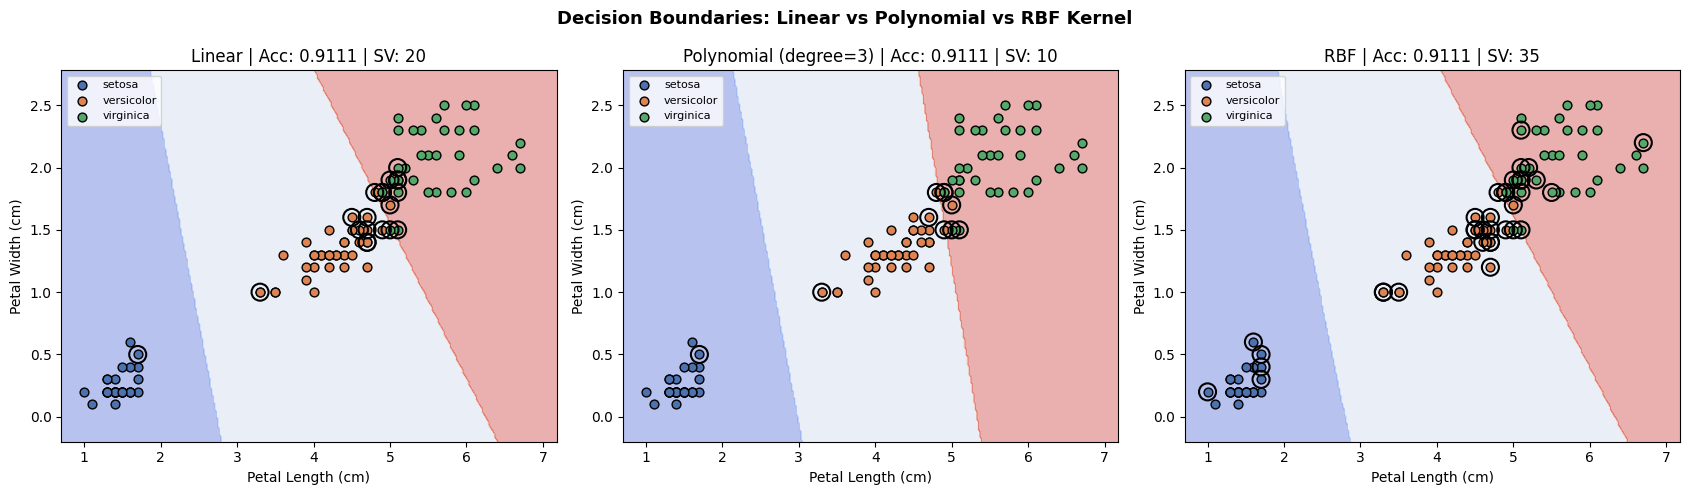

In [11]:
# Visualisasi decision boundaries ketiga kernel (2 fitur: petal length & petal width)
X_2d = X[:, 2:4]  # Ambil fitur paling informatif
X_2d_train, X_2d_test, y_2d_train, y_2d_test = train_test_split(
    X_2d, y, test_size=0.3, random_state=2024
)

x_min, x_max = X_2d[:, 0].min() - 0.3, X_2d[:, 0].max() + 0.3
y_min, y_max = X_2d[:, 1].min() - 0.3, X_2d[:, 1].max() + 0.3
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

kernel_list  = ['linear', 'poly', 'rbf']
kernel_names = ['Linear', 'Polynomial (degree=3)', 'RBF']
colors_pts   = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, kernel, name in zip(axes, kernel_list, kernel_names):
    svm_2d = SVC(kernel=kernel, degree=3, random_state=2024)
    svm_2d.fit(X_2d_train, y_2d_train)
    acc_2d = svm_2d.score(X_2d_test, y_2d_test)

    Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')

    for cls, color in zip([0, 1, 2], colors_pts):
        mask = y_2d_train == cls
        ax.scatter(X_2d_train[mask, 0], X_2d_train[mask, 1],
                   color=color, edgecolors='k', s=40,
                   label=iris.target_names[cls])

    sv_2d = svm_2d.support_vectors_
    ax.scatter(sv_2d[:, 0], sv_2d[:, 1], s=150,
               facecolors='none', edgecolors='black', linewidths=1.5)

    ax.set_xlabel('Petal Length (cm)')
    ax.set_ylabel('Petal Width (cm)')
    ax.set_title(f'{name} | Acc: {acc_2d:.4f} | SV: {sv_2d.shape[0]}')
    ax.legend(fontsize=8)

plt.suptitle('Decision Boundaries: Linear vs Polynomial vs RBF Kernel',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 3. Tuning Hyperparameter SVM

### Penjelasan Teori

SVM memiliki beberapa hyperparameter kritis yang sangat mempengaruhi performa model:

**Parameter `C` (Regularization Parameter):**
- Mengontrol trade-off antara memaksimalkan margin dan meminimalkan kesalahan klasifikasi.
- `C` tinggi = lebih sedikit kesalahan training (margin sempit, potensi overfit).
- `C` rendah = lebih banyak toleransi misklasifikasi (margin lebar, lebih general).

**Parameter `gamma` (untuk kernel RBF dan Polynomial):**
- Mengontrol seberapa jauh pengaruh satu training sample.
- `gamma` tinggi = setiap sample memiliki pengaruh sempit, model sangat kompleks (overfit).
- `gamma` rendah = setiap sample memiliki pengaruh luas, model lebih smooth (underfit).
- Nilai default `'scale'` = `1 / (n_features * X.var())`.

**Parameter `degree` (untuk Polynomial kernel):**
- Menentukan derajat fungsi polinomial.
- Nilai lebih tinggi = boundary lebih kompleks.

**Strategi tuning:** Gunakan `GridSearchCV` untuk mencari kombinasi terbaik secara systematic. Untuk SVM, grid yang umum adalah `C` dan `gamma` dalam skala logaritmik.


In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.datasets import load_breast_cancer

# Gunakan Breast Cancer untuk tuning SVM
bc = load_breast_cancer()
X_bc, y_bc = bc.data, bc.target
X_bc_train, X_bc_test, y_bc_train, y_bc_test = train_test_split(
    X_bc, y_bc, test_size=0.3, random_state=2024
)

# Definisikan grid hyperparameter
param_grid = {
    'svm__C':      [0.1, 1, 10, 100],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma':  ['scale', 'auto', 0.001, 0.01],
}

pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),  # SVM sensitif terhadap skala fitur
    ('svm', SVC(probability=True, random_state=2024))
])

gs_svm = GridSearchCV(
    pipeline_svm, param_grid,
    cv=5, scoring='accuracy', n_jobs=-1
)
gs_svm.fit(X_bc_train, y_bc_train)

print(f"Parameter terbaik: {gs_svm.best_params_}")
print(f"CV Accuracy terbaik: {gs_svm.best_score_:.4f}")
print(f"Test Accuracy:       {gs_svm.best_estimator_.score(X_bc_test, y_bc_test):.4f}")


Parameter terbaik: {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
CV Accuracy terbaik: 0.9774
Test Accuracy:       0.9825


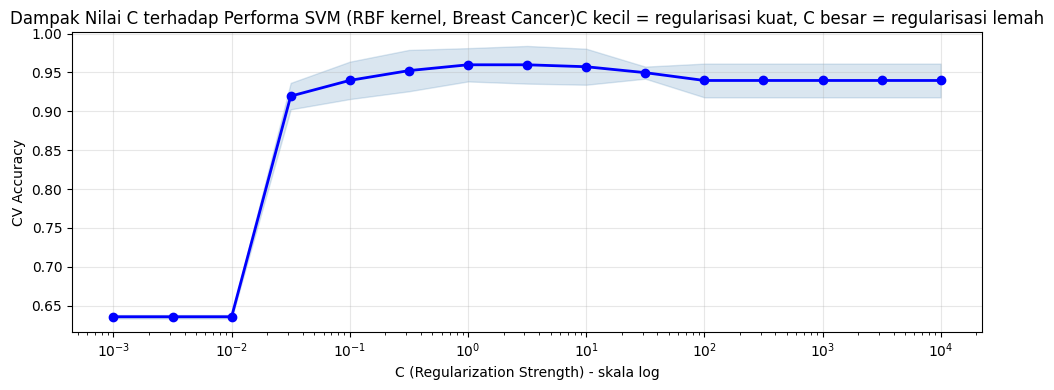

In [14]:
# Visualisasi dampak C terhadap CV accuracy (RBF kernel)
param_grid_c = {'C': np.logspace(-3, 4, 15), 'kernel': ['rbf']}

pipeline_c = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=2024))
])

gs_c = GridSearchCV(
    Pipeline([('scaler', StandardScaler()), ('svm', SVC(random_state=2024))]),
    {'svm__C': np.logspace(-3, 4, 15), 'svm__kernel': ['rbf']},
    cv=5, scoring='accuracy', n_jobs=-1
)
gs_c.fit(X_bc_train, y_bc_train)

plt.figure(figsize=(10, 4))
plt.semilogx(
    np.logspace(-3, 4, 15),
    gs_c.cv_results_['mean_test_score'],
    'b-o', linewidth=2, markersize=6
)
plt.fill_between(
    np.logspace(-3, 4, 15),
    gs_c.cv_results_['mean_test_score'] - gs_c.cv_results_['std_test_score'],
    gs_c.cv_results_['mean_test_score'] + gs_c.cv_results_['std_test_score'],
    alpha=0.2, color='steelblue'
)
plt.xlabel('C (Regularization Strength) - skala log')
plt.ylabel('CV Accuracy')
plt.title('Dampak Nilai C terhadap Performa SVM (RBF kernel, Breast Cancer)''C kecil = regularisasi kuat, C besar = regularisasi lemah')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


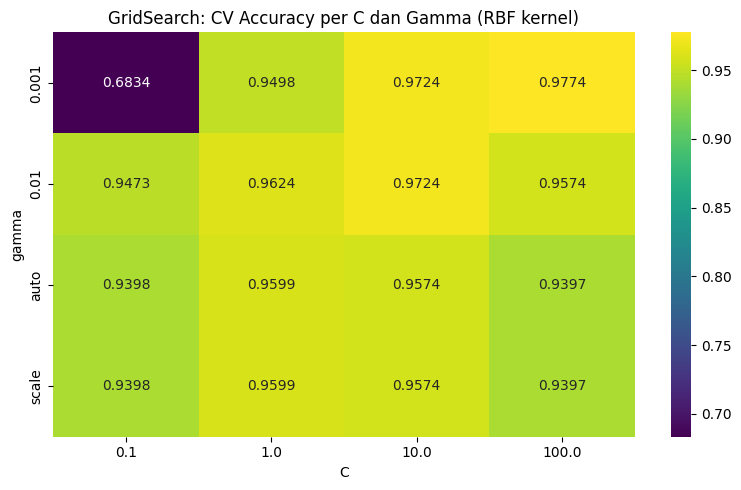

In [15]:
# Heatmap C vs gamma
results_heat = pd.DataFrame(gs_svm.cv_results_)
results_rbf  = results_heat[results_heat['param_svm__kernel'] == 'rbf'].copy()
results_rbf['param_svm__C']     = results_rbf['param_svm__C'].astype(str)
results_rbf['param_svm__gamma'] = results_rbf['param_svm__gamma'].astype(str)

try:
    pivot_heat = results_rbf.pivot_table(
        values='mean_test_score',
        index='param_svm__gamma',
        columns='param_svm__C'
    )
    plt.figure(figsize=(8, 5))
    sns.heatmap(pivot_heat, annot=True, fmt='.4f', cmap='viridis')
    plt.title('GridSearch: CV Accuracy per C dan Gamma (RBF kernel)')
    plt.xlabel('C')
    plt.ylabel('gamma')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Catatan visualisasi heatmap: {e}")
    print("Hasil numerik ditampilkan di atas.")


---
## 4. SVM pada Data Berdimensi Tinggi

### Penjelasan Teori

SVM sangat cocok untuk data berdimensi tinggi karena:
1. Algoritma optimasi SVM hanya bergantung pada dot products antar data point, bukan dimensi fitur secara langsung.
2. Kernel trick memungkinkan SVM beroperasi secara efisien bahkan ketika jumlah fitur sangat besar.
3. Regularisasi melalui parameter `C` mencegah overfitting meski dimensi tinggi.

**Tantangan data berdimensi tinggi:**
- Banyak fitur yang mungkin tidak relevan atau redundan.
- Risiko curse of dimensionality.
- Waktu training lebih lama.

**Solusi:** Kombinasikan SVM dengan PCA atau seleksi fitur untuk mengurangi dimensi sebelum training, atau gunakan kernel linear yang lebih efisien untuk dataset dengan banyak fitur.

**Dataset "wide" (features >> samples):** SVM dengan linear kernel sering menjadi pilihan terbaik dalam kasus ini, seperti pada analisis teks atau data genomik.


In [16]:
from sklearn.datasets import make_classification
from sklearn.decomposition import PCA

# Dataset berdimensi sangat tinggi: 1000 fitur, 1000 sampel
X_hd, y_hd = make_classification(
    n_samples=1000, n_features=1000,
    n_informative=50, n_redundant=0, random_state=2024
)

X_hd_train, X_hd_test, y_hd_train, y_hd_test = train_test_split(
    X_hd, y_hd, test_size=0.3, random_state=2024
)

print(f"Shape data berdimensi tinggi: {X_hd.shape}")
print(f"Jumlah fitur informatif: 50 dari 1000 total fitur")
print(f"Rasio features/samples: {X_hd.shape[1]/X_hd.shape[0]:.1f}x")


Shape data berdimensi tinggi: (1000, 1000)
Jumlah fitur informatif: 50 dari 1000 total fitur
Rasio features/samples: 1.0x


In [17]:
# SVM dengan linear kernel pada data berdimensi tinggi
from sklearn.pipeline import Pipeline

pipeline_hd = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear', C=0.1, random_state=2024))
])

print("Training SVM (linear) pada 1000 fitur...")
pipeline_hd.fit(X_hd_train, y_hd_train)
acc_hd = pipeline_hd.score(X_hd_test, y_hd_test)
print(f"Accuracy tanpa reduksi dimensi: {acc_hd:.4f}")


Training SVM (linear) pada 1000 fitur...
Accuracy tanpa reduksi dimensi: 0.6700


In [18]:
# Bandingkan: SVM langsung vs SVM setelah PCA
pca_components = [10, 50, 100, 200]
results_pca_svm = [{'n_components': 'Tanpa PCA', 'accuracy': acc_hd}]

for n_comp in pca_components:
    pipe_pca = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n_comp)),
        ('svm', SVC(kernel='rbf', C=1.0, random_state=2024))
    ])
    pipe_pca.fit(X_hd_train, y_hd_train)
    acc_pca = pipe_pca.score(X_hd_test, y_hd_test)
    results_pca_svm.append({'n_components': f'PCA ({n_comp})', 'accuracy': round(acc_pca, 4)})
    print(f"SVM + PCA ({n_comp} components): Accuracy = {acc_pca:.4f}")

print()
display(pd.DataFrame(results_pca_svm))


SVM + PCA (10 components): Accuracy = 0.5267
SVM + PCA (50 components): Accuracy = 0.5367
SVM + PCA (100 components): Accuracy = 0.5700
SVM + PCA (200 components): Accuracy = 0.5400



,n_components,accuracy
0,Tanpa PCA,0.6700
1,PCA (10),0.5267
2,PCA (50),0.5367
3,PCA (100),0.5700
4,PCA (200),0.5400


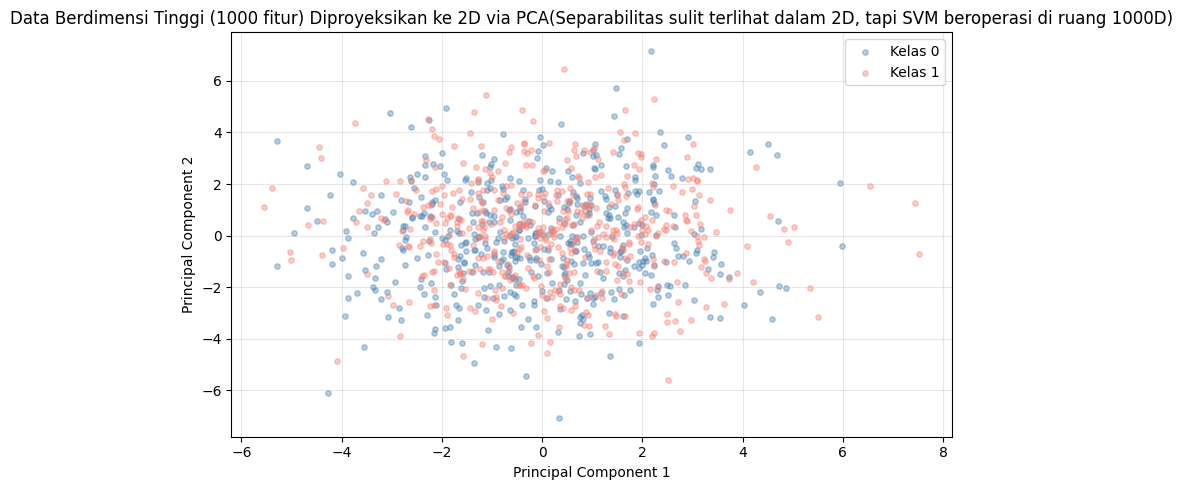

Varians yang dijelaskan oleh 2 PC pertama: 0.79%
(Rendahnya varians menunjukkan informasi tersebar di banyak dimensi)


In [20]:
# Visualisasi data berdimensi tinggi di 2D via PCA
pca_vis = PCA(n_components=2)
X_hd_pca = pca_vis.fit_transform(StandardScaler().fit_transform(X_hd))

plt.figure(figsize=(8, 5))
plt.scatter(X_hd_pca[y_hd==0, 0], X_hd_pca[y_hd==0, 1],
            color='steelblue', alpha=0.4, s=15, label='Kelas 0')
plt.scatter(X_hd_pca[y_hd==1, 0], X_hd_pca[y_hd==1, 1],
            color='salmon', alpha=0.4, s=15, label='Kelas 1')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Data Berdimensi Tinggi (1000 fitur) Diproyeksikan ke 2D via PCA''(Separabilitas sulit terlihat dalam 2D, tapi SVM beroperasi di ruang 1000D)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

var_explained = pca_vis.explained_variance_ratio_.sum()
print(f"Varians yang dijelaskan oleh 2 PC pertama: {var_explained:.2%}")
print("(Rendahnya varians menunjukkan informasi tersebar di banyak dimensi)")


---
## 5. Evaluasi Model SVM

### Penjelasan Teori

Evaluasi model SVM menggunakan metrik yang sama dengan model klasifikasi lain. Satu hal yang perlu diperhatikan: **SVM secara default tidak menghasilkan probabilitas**. Untuk mendapatkan probabilitas (yang diperlukan untuk ROC curve), kita harus mengatur `probability=True` saat inisialisasi `SVC()`. Ini menggunakan Platt scaling di balik layar, yang menambah waktu training namun memungkinkan evaluasi probabilistik.

**Metrik evaluasi utama:**
- **Accuracy:** Proporsi prediksi benar dari total.
- **Precision:** Dari semua yang diprediksi positif, berapa yang benar-benar positif?
- **Recall:** Dari semua yang benar-benar positif, berapa yang terdeteksi?
- **F1-Score:** Harmonic mean dari precision dan recall.
- **ROC-AUC:** Area Under ROC Curve. Mengukur kemampuan diskriminasi model di semua threshold.


In [21]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_curve, auc, confusion_matrix, classification_report
)
from sklearn.preprocessing import label_binarize

# SVM terbaik dari GridSearchCV (Breast Cancer dataset)
best_svm = gs_svm.best_estimator_
y_pred_best = best_svm.predict(X_bc_test)
y_prob_best = best_svm.predict_proba(X_bc_test)[:, 1]

# Hitung semua metrik
acc   = accuracy_score(y_bc_test, y_pred_best)
prec  = precision_score(y_bc_test, y_pred_best)
rec   = recall_score(y_bc_test, y_pred_best)
f1    = f1_score(y_bc_test, y_pred_best)
fpr, tpr, _ = roc_curve(y_bc_test, y_prob_best)
roc_auc_val = auc(fpr, tpr)

print("Evaluasi SVM Terbaik (Breast Cancer Dataset):")
print(f"  Accuracy:   {acc:.4f}")
print(f"  Precision:  {prec:.4f}")
print(f"  Recall:     {rec:.4f}")
print(f"  F1-Score:   {f1:.4f}")
print(f"  ROC-AUC:    {roc_auc_val:.4f}")


Evaluasi SVM Terbaik (Breast Cancer Dataset):
  Accuracy:   0.9825
  Precision:  0.9810
  Recall:     0.9904
  F1-Score:   0.9856
  ROC-AUC:    0.9976


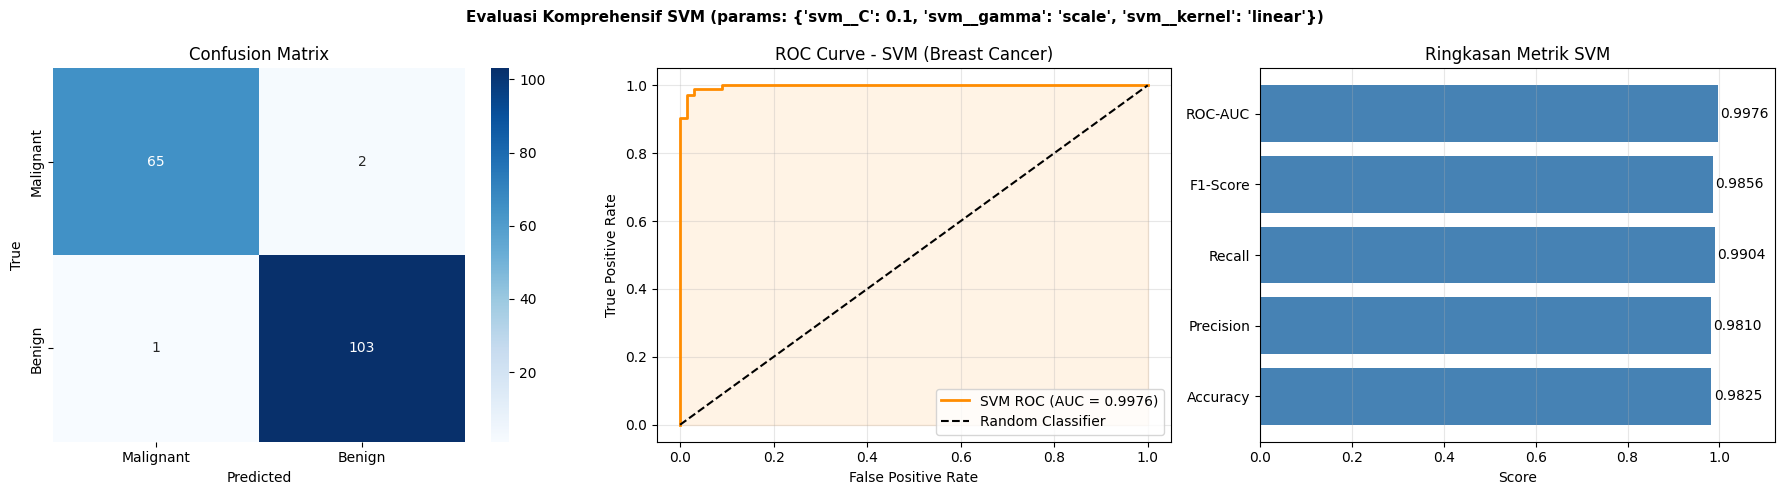

In [22]:
# Visualisasi komprehensif evaluasi SVM
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Confusion Matrix
cm = confusion_matrix(y_bc_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'], ax=ax1)
ax1.set_xlabel('Predicted')
ax1.set_ylabel('True')
ax1.set_title('Confusion Matrix')

# Panel 2: ROC Curve
ax2.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'SVM ROC (AUC = {roc_auc_val:.4f})')
ax2.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax2.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve - SVM (Breast Cancer)')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

# Panel 3: Ringkasan metrik
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
values  = [acc, prec, rec, f1, roc_auc_val]
bars = ax3.barh(metrics, values, color='steelblue')
for bar, val in zip(bars, values):
    ax3.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=10)
ax3.set_xlim(0, 1.12)
ax3.set_xlabel('Score')
ax3.set_title('Ringkasan Metrik SVM')
ax3.grid(True, alpha=0.3, axis='x')

plt.suptitle(f'Evaluasi Komprehensif SVM (params: {gs_svm.best_params_})',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 6. Latihan Praktis: Perbandingan Komprehensif SVM

### Deskripsi

Pada bagian ini kita membandingkan semua konfigurasi SVM yang telah dipelajari secara menyeluruh pada Breast Cancer dataset menggunakan cross-validation.


In [23]:
from sklearn.model_selection import cross_val_score

# Definisikan semua konfigurasi SVM yang akan dibandingkan
svm_configs = {
    'SVM Linear (C=1)':    Pipeline([('sc', StandardScaler()), ('svm', SVC(kernel='linear', C=1, random_state=2024))]),
    'SVM Linear (C=10)':   Pipeline([('sc', StandardScaler()), ('svm', SVC(kernel='linear', C=10, random_state=2024))]),
    'SVM Poly (degree=3)': Pipeline([('sc', StandardScaler()), ('svm', SVC(kernel='poly', degree=3, C=1, random_state=2024))]),
    'SVM RBF (C=1)':       Pipeline([('sc', StandardScaler()), ('svm', SVC(kernel='rbf', C=1, gamma='scale', random_state=2024))]),
    'SVM RBF (C=10)':      Pipeline([('sc', StandardScaler()), ('svm', SVC(kernel='rbf', C=10, gamma='scale', random_state=2024))]),
    'SVM GridSearch Best': gs_svm.best_estimator_,
}

comparison_results = []
for name, pipe in svm_configs.items():
    cv_scores = cross_val_score(pipe, X_bc_train, y_bc_train, cv=5, scoring='accuracy')
    pipe.fit(X_bc_train, y_bc_train)
    test_acc = pipe.score(X_bc_test, y_bc_test)
    comparison_results.append({
        'Konfigurasi':      name,
        'CV Acc Mean':      round(cv_scores.mean(), 4),
        'CV Acc Std':       round(cv_scores.std(), 4),
        'Test Accuracy':    round(test_acc, 4),
    })

comp_df = pd.DataFrame(comparison_results).sort_values('Test Accuracy', ascending=False)
print("Perbandingan Komprehensif Konfigurasi SVM (Breast Cancer):")
display(comp_df.reset_index(drop=True))


Perbandingan Komprehensif Konfigurasi SVM (Breast Cancer):


,Konfigurasi,CV Acc Mean,CV Acc Std,Test Accuracy
0,SVM Linear (C=1),0.9724,0.0201,0.9825
1,SVM RBF (C=1),0.9599,0.0214,0.9825
2,SVM GridSearch Best,0.9774,0.0146,0.9825
3,SVM RBF (C=10),0.9574,0.0232,0.9825
4,SVM Linear (C=10),0.9548,0.0234,0.9591
5,SVM Poly (degree=3),0.8921,0.0443,0.8713


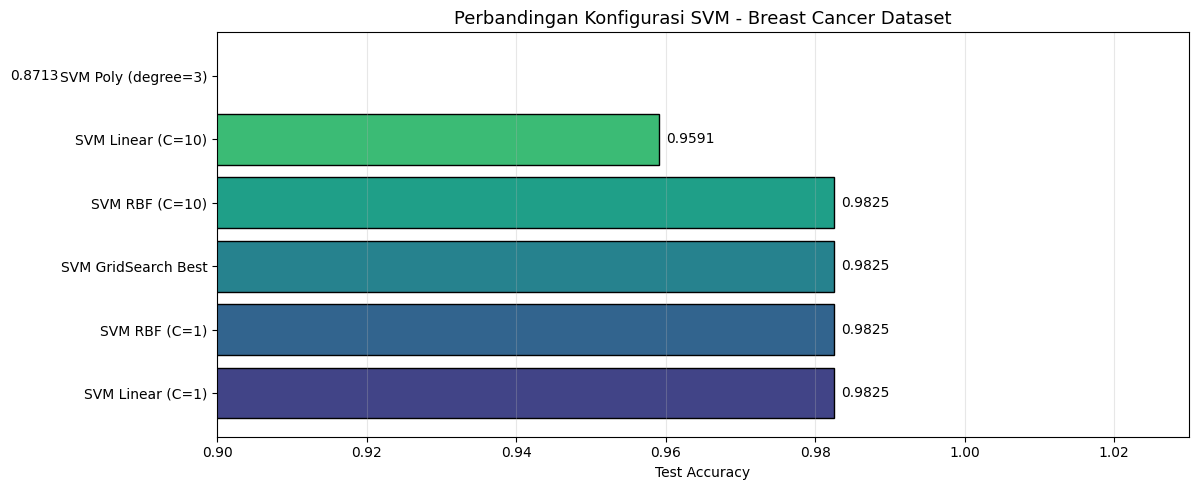

In [24]:
# Bar chart perbandingan test accuracy
fig, ax = plt.subplots(figsize=(12, 5))
bar_colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(comp_df)))
bars = ax.barh(comp_df['Konfigurasi'], comp_df['Test Accuracy'],
               color=bar_colors, edgecolor='black')
for bar, val, std in zip(bars, comp_df['Test Accuracy'], comp_df['CV Acc Std']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)
ax.set_xlim(0.9, 1.03)
ax.set_xlabel('Test Accuracy')
ax.set_title('Perbandingan Konfigurasi SVM - Breast Cancer Dataset', fontsize=13)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


---
## Ringkasan Chapter 7

| Konsep | Kelas/Parameter | Deskripsi |
|--------|----------------|-----------|
| SVM Klasifikasi | `SVC()` | Mencari hyperplane dengan margin maksimum |
| SVM Regresi | `SVR()` | Prediksi nilai kontinu dengan margin epsilon |
| Linear Kernel | `kernel='linear'` | Cocok untuk data linear separable atau banyak fitur |
| Polynomial Kernel | `kernel='poly', degree=N` | Hubungan polinomial antar fitur |
| RBF Kernel | `kernel='rbf'` | Kernel paling umum, hubungan non-linear kompleks |
| Regularisasi | `C` | Besar = sedikit misklasifikasi, kecil = margin lebar |
| Pengaruh lokal | `gamma` | Tinggi = pengaruh sempit, rendah = pengaruh luas |
| Probabilitas | `probability=True` | Aktifkan untuk ROC curve (menggunakan Platt scaling) |

### Poin Kunci untuk Diingat:

1. **SVM memaksimalkan margin** antara kelas melalui support vectors. Hanya titik-titik paling dekat dengan boundary yang menentukan model, bukan seluruh dataset.

2. **Kernel trick** memungkinkan SVM menangani data non-linear dengan memetakannya ke dimensi lebih tinggi tanpa komputasi eksplisit di sana.

3. **Selalu standardisasi fitur** sebelum SVM. Parameter `C` dan `gamma` sangat sensitif terhadap skala fitur yang berbeda-beda.

4. **Pilihan kernel:** Mulai dengan RBF sebagai default karena fleksibel. Gunakan linear untuk data berdimensi sangat tinggi atau dataset besar. Polynomial untuk data dengan hubungan polinomial yang diketahui.

5. **Tuning `C` dan `gamma` secara bersamaan** menggunakan `GridSearchCV` dalam skala logaritmik (misalnya `[0.001, 0.01, 0.1, 1, 10, 100]`).

6. **SVM lambat pada dataset besar:** Kompleksitas training O(n^2) hingga O(n^3) terhadap jumlah sampel. Pertimbangkan `LinearSVC` atau `SGDClassifier` untuk dataset sangat besar.
